# 03 — Valuation Charts / Gráficos de Valuation

**English:** This notebook creates the charts used to communicate the GMAT3 relative valuation story. The goal is not to add new assumptions, but to turn the valuation outputs from notebook 02 into clear visuals for a report or executive summary slide.

**Português:** Este notebook cria os gráficos usados para comunicar a história do valuation relativo da GMAT3. O objetivo não é adicionar novas premissas, mas transformar os resultados do notebook 02 em visuais claros para relatório ou slide executivo.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

plt.style.use("seaborn-v0_8-whitegrid")


## 1. Load Valuation Outputs / Carregar Saídas do Valuation

**English:** The notebook uses the CSV files exported by notebook 02. These files already contain the expanded peer multiples, valuation scenarios, and current market positioning.

**Português:** O notebook usa os arquivos CSV exportados pelo notebook 02. Esses arquivos já contêm os múltiplos do peer group expandido, os cenários de valuation e o posicionamento atual de mercado.


In [2]:
outputs_dir = Path("../outputs")
charts_dir = Path("../charts")
charts_dir.mkdir(parents=True, exist_ok=True)

positioning_df = pd.read_csv(outputs_dir / "current_market_positioning.csv")
scenarios_df = pd.read_csv(outputs_dir / "gmat3_relative_valuation_scenarios.csv")
peer_stats_df = pd.read_csv(outputs_dir / "expanded_peer_stats.csv")

current_price = scenarios_df.loc[
    scenarios_df["scenario"].eq("Expanded LatAm ex-Distressed Median"),
    "implied_price_per_share",
].iloc[0] / (
    1 + scenarios_df.loc[
        scenarios_df["scenario"].eq("Expanded LatAm ex-Distressed Median"),
        "upside_downside_pct",
    ].iloc[0] / 100
)

display(positioning_df)
display(scenarios_df)
display(peer_stats_df)


,ticker,company,country,peer_quality,ev_ebitda_multiple,include_in_trading_comps,multiple_source
0,PCAR3.SA,GPA,Brazil,Distressed / Turnaround Peer,2.30,True,notebook_01_annualized_1q26
1,ASAI3.SA,Assai,Brazil,Core Peer,6.10,True,notebook_01_annualized_1q26
2,GMAT3.SA,Grupo Mateus,Brazil,Target,6.58,False,notebook_01_annualized_1q26
3,CHDRAUIB.MX,Grupo Comercial Chedraui,Mexico,LatAm Food Retail Peer,7.22,True,yfinance
4,SORIANAB.MX,Organizacion Soriana,Mexico,LatAm Food Retail Peer,7.40,True,yfinance
5,WALMEX.MX,Walmart de Mexico,Mexico,High Quality LatAm Peer,9.84,True,yfinance
6,CENCOSUD.SN,Cencosud,Chile,LatAm Multi-format Retail Peer,10.86,True,yfinance


,scenario,applied_ev_ebitda_multiple,peer_count,included_peers,methodology,target_ebitda_annualized,implied_enterprise_value,target_net_debt,implied_equity_value,implied_price_per_share,upside_downside_pct
0,Conservative Case,6.38,6,"PCAR3.SA, ASAI3.SA, CHDRAUIB.MX, SORIANAB.MX, ...","25th percentile of full traded peer set, inclu...",1600,"10,212.56",736,"9,476.56",4.12,-3.28
1,Domestic Listed Median,4.20,2,"ASAI3.SA, PCAR3.SA","Median of Brazilian listed peers, including di...",1600,"6,721.81",736,"5,985.81",2.60,-38.91
2,Domestic Core Case,6.10,1,ASAI3.SA,Assai-only case as closest domestic listed com...,1600,"9,767.67",736,"9,031.67",3.93,-7.82
3,Expanded LatAm ex-Distressed Median,7.40,5,"ASAI3.SA, CHDRAUIB.MX, SORIANAB.MX, WALMEX.MX,...",Median of traded peers excluding distressed GP...,1600,"11,836.80",736,"11,100.80",4.83,13.29
4,Expanded LatAm including GPA Median,7.31,6,"PCAR3.SA, ASAI3.SA, CHDRAUIB.MX, SORIANAB.MX, ...","Median of all traded peers, including GPA",1600,"11,692.00",736,"10,956.00",4.76,11.82
5,Upside Case,9.84,5,"ASAI3.SA, CHDRAUIB.MX, SORIANAB.MX, WALMEX.MX,...",Higher of GMAT3 current EV/EBITDA and ex-distr...,1600,"15,745.60",736,"15,009.60",6.53,53.19


,peer_set,count,mean,median,p25,p75,min,max
0,Full Trading Peer Set,6,7.29,7.31,6.38,9.23,2.30,10.86
1,Ex-Distressed Trading Peer Set,5,8.28,7.40,7.22,9.84,6.10,10.86


## 2. EV/EBITDA Peer Comparison / Comparação EV/EBITDA dos Pares

**English:** This chart shows where GMAT3 trades versus the peer group. GPA is highlighted as a distressed / turnaround peer, while GMAT3 is highlighted as the target company.

**Português:** Este gráfico mostra onde a GMAT3 negocia em relação ao peer group. GPA é destacada como empresa distressed / turnaround, enquanto GMAT3 é destacada como a empresa-alvo.


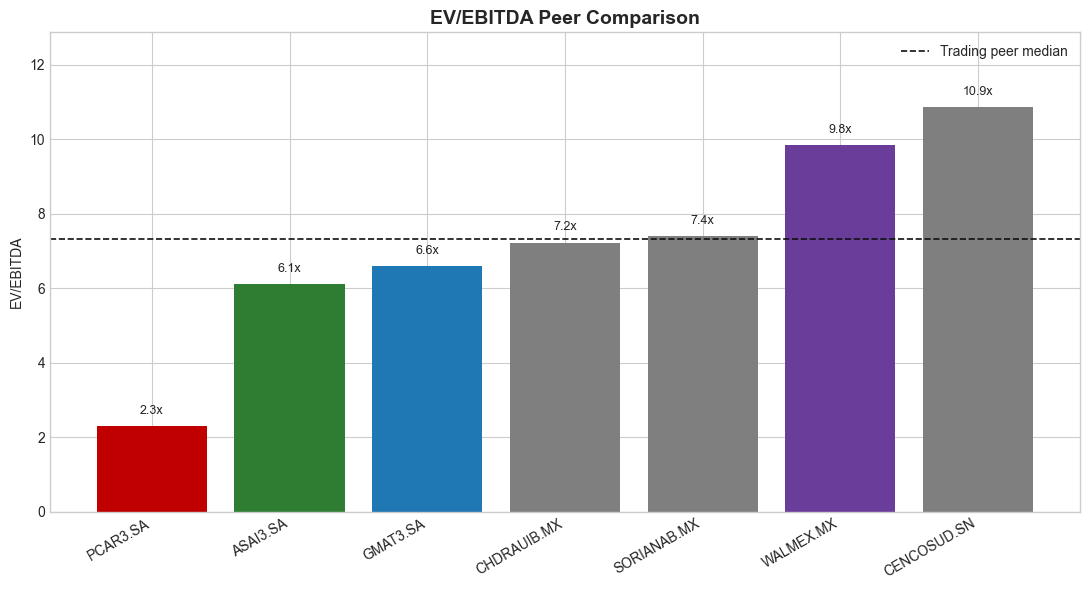

Saved chart: ../charts/ev_ebitda_peer_comparison.png


In [3]:
peer_chart_df = positioning_df.sort_values("ev_ebitda_multiple").copy()

color_map = {
    "Target": "#1F77B4",
    "Distressed / Turnaround Peer": "#C00000",
    "Core Peer": "#2E7D32",
    "High Quality LatAm Peer": "#6A3D9A",
    "LatAm Food Retail Peer": "#7F7F7F",
    "LatAm Multi-format Retail Peer": "#7F7F7F",
}
bar_colors = peer_chart_df["peer_quality"].map(color_map).fillna("#7F7F7F")

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(peer_chart_df["ticker"], peer_chart_df["ev_ebitda_multiple"], color=bar_colors)
ax.axhline(
    peer_chart_df.loc[peer_chart_df["include_in_trading_comps"], "ev_ebitda_multiple"].median(),
    color="#111111",
    linestyle="--",
    linewidth=1.2,
    label="Trading peer median",
)

for index, value in enumerate(peer_chart_df["ev_ebitda_multiple"]):
    ax.text(index, value + 0.25, f"{value:.1f}x", ha="center", va="bottom", fontsize=9)

ax.set_title("EV/EBITDA Peer Comparison", fontsize=14, fontweight="bold")
ax.set_ylabel("EV/EBITDA")
ax.set_xlabel("")
ax.legend(frameon=False)
ax.set_ylim(0, peer_chart_df["ev_ebitda_multiple"].max() + 2)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

chart_path = charts_dir / "ev_ebitda_peer_comparison.png"
plt.savefig(chart_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved chart: {chart_path}")


## 3. Scenario Multiples / Múltiplos por Cenário

**English:** This chart explains why peer selection matters. Including GPA pulls the domestic benchmark down, while the LatAm ex-distressed scenario produces a more normalized valuation reference.

**Português:** Este gráfico explica por que a escolha do peer group importa. Incluir GPA puxa o benchmark doméstico para baixo, enquanto o cenário LatAm ex-distressed produz uma referência de valuation mais normalizada.


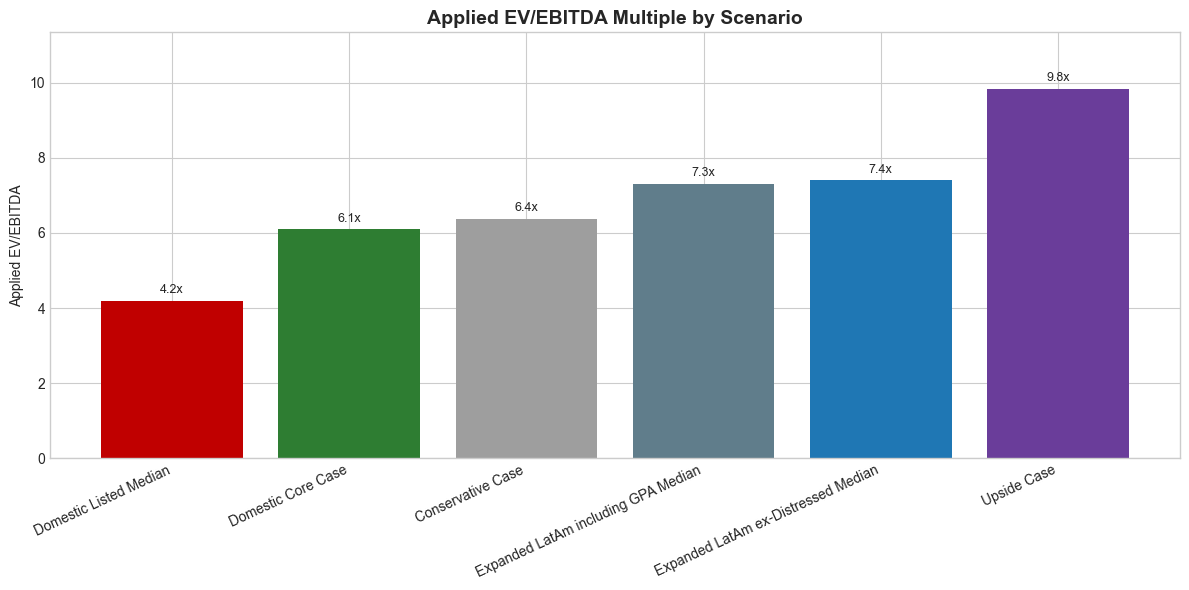

Saved chart: ../charts/scenario_multiples.png


In [4]:
scenario_order = [
    "Domestic Listed Median",
    "Domestic Core Case",
    "Conservative Case",
    "Expanded LatAm including GPA Median",
    "Expanded LatAm ex-Distressed Median",
    "Upside Case",
]
scenario_multiples_df = scenarios_df.set_index("scenario").loc[scenario_order].reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
colors = ["#C00000", "#2E7D32", "#9E9E9E", "#607D8B", "#1F77B4", "#6A3D9A"]
ax.bar(
    scenario_multiples_df["scenario"],
    scenario_multiples_df["applied_ev_ebitda_multiple"],
    color=colors,
)

for index, value in enumerate(scenario_multiples_df["applied_ev_ebitda_multiple"]):
    ax.text(index, value + 0.2, f"{value:.1f}x", ha="center", fontsize=9)

ax.set_title("Applied EV/EBITDA Multiple by Scenario", fontsize=14, fontweight="bold")
ax.set_ylabel("Applied EV/EBITDA")
ax.set_xlabel("")
ax.set_ylim(0, scenario_multiples_df["applied_ev_ebitda_multiple"].max() + 1.5)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

chart_path = charts_dir / "scenario_multiples.png"
plt.savefig(chart_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved chart: {chart_path}")


## 4. Fair Price by Scenario / Preço Justo por Cenário

**English:** This chart compares each implied fair price with the current GMAT3 share price. It is the clearest visual for the final executive-summary block: current price versus fair value range.

**Português:** Este gráfico compara cada preço justo implícito com o preço atual da ação da GMAT3. É o visual mais claro para o bloco do sumário executivo: preço atual versus faixa de valor justo.


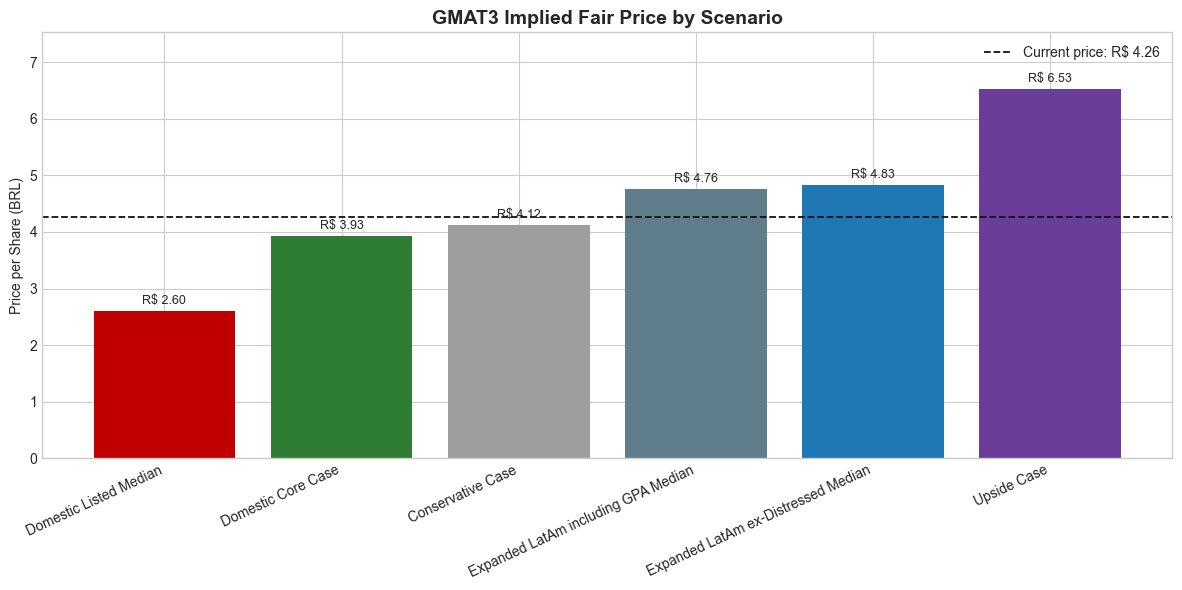

Saved chart: ../charts/fair_price_by_scenario.png


In [5]:
fair_price_df = scenarios_df.set_index("scenario").loc[scenario_order].reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
bar_colors = ["#C00000", "#2E7D32", "#9E9E9E", "#607D8B", "#1F77B4", "#6A3D9A"]
ax.bar(fair_price_df["scenario"], fair_price_df["implied_price_per_share"], color=bar_colors)
ax.axhline(current_price, color="#111111", linestyle="--", linewidth=1.3, label=f"Current price: R$ {current_price:.2f}")

for index, value in enumerate(fair_price_df["implied_price_per_share"]):
    ax.text(index, value + 0.12, f"R$ {value:.2f}", ha="center", fontsize=9)

ax.set_title("GMAT3 Implied Fair Price by Scenario", fontsize=14, fontweight="bold")
ax.set_ylabel("Price per Share (BRL)")
ax.set_xlabel("")
ax.legend(frameon=False)
ax.set_ylim(0, fair_price_df["implied_price_per_share"].max() + 1.0)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

chart_path = charts_dir / "fair_price_by_scenario.png"
plt.savefig(chart_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved chart: {chart_path}")


## 5. Upside / Downside by Scenario / Upside ou Downside por Cenário

**English:** This chart translates valuation into potential return. The base case is positive, but not extreme, which supports a constructive but balanced thesis.

**Português:** Este gráfico traduz valuation em retorno potencial. O cenário base é positivo, mas não extremo, o que sustenta uma tese construtiva, porém equilibrada.


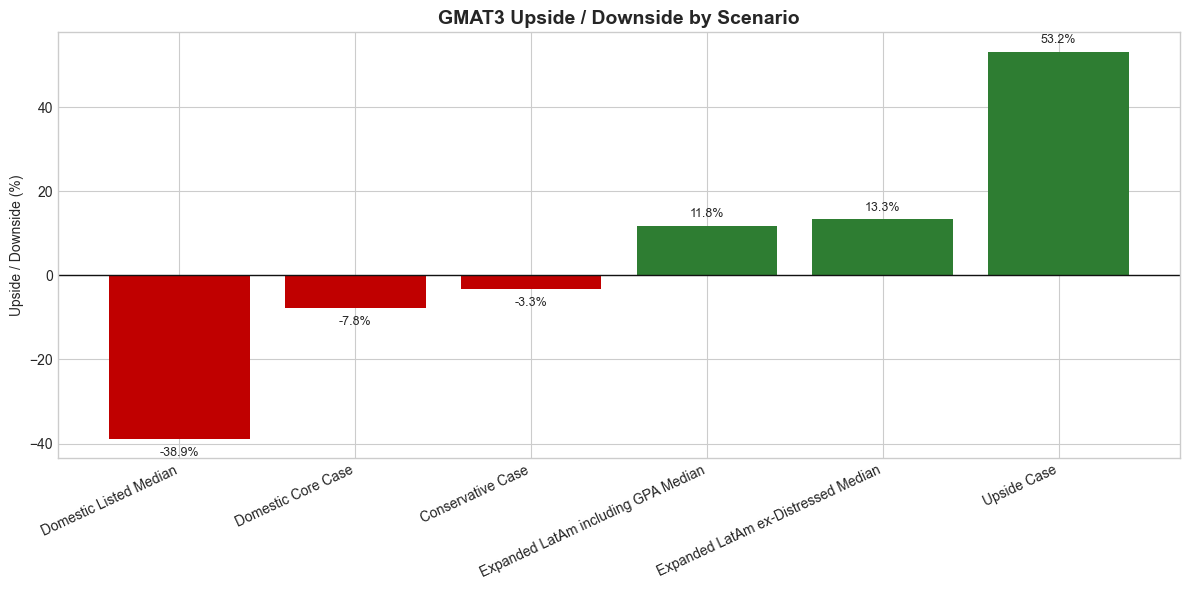

Saved chart: ../charts/upside_downside_by_scenario.png


In [6]:
upside_df = fair_price_df.copy()
upside_colors = np.where(upside_df["upside_downside_pct"] >= 0, "#2E7D32", "#C00000")

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(upside_df["scenario"], upside_df["upside_downside_pct"], color=upside_colors)
ax.axhline(0, color="#111111", linewidth=1)

for index, value in enumerate(upside_df["upside_downside_pct"]):
    label_y = value + 2 if value >= 0 else value - 4
    ax.text(index, label_y, f"{value:.1f}%", ha="center", fontsize=9)

ax.set_title("GMAT3 Upside / Downside by Scenario", fontsize=14, fontweight="bold")
ax.set_ylabel("Upside / Downside (%)")
ax.set_xlabel("")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

chart_path = charts_dir / "upside_downside_by_scenario.png"
plt.savefig(chart_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved chart: {chart_path}")


## 6. Football Field Chart / Gráfico Football Field

**English:** A football field chart presents valuation as a range instead of pretending there is one exact answer. This is useful for explaining that the fair value depends on peer selection and scenario judgment.

**Português:** O football field apresenta o valuation como uma faixa em vez de fingir que existe uma resposta exata. Isso é útil para explicar que o valor justo depende da escolha dos peers e do julgamento do cenário.


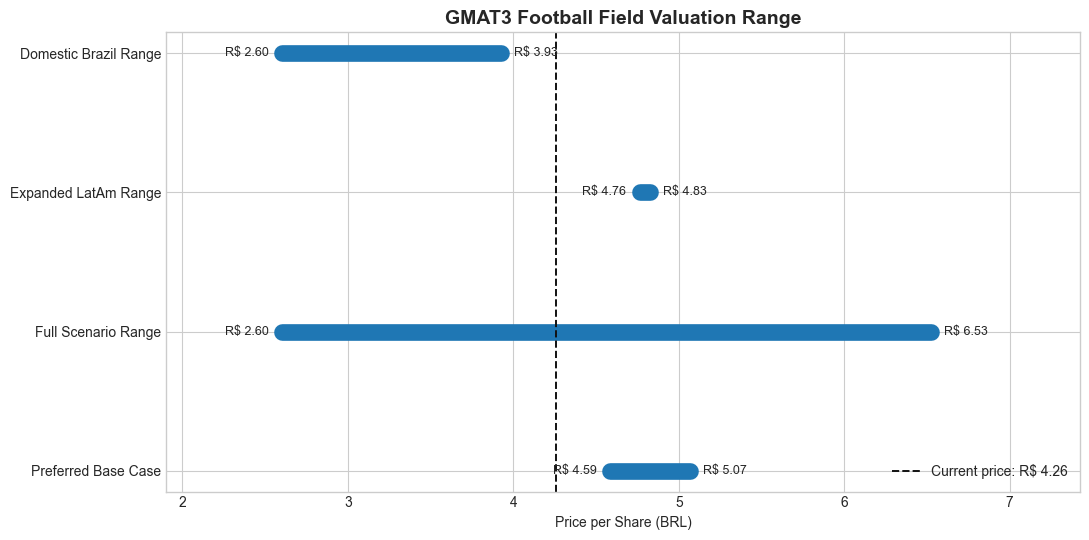

Saved chart: ../charts/football_field_chart.png


In [7]:
scenario_price_lookup = scenarios_df.set_index("scenario")["implied_price_per_share"]
football_ranges = pd.DataFrame(
    {
        "range_name": [
            "Domestic Brazil Range",
            "Expanded LatAm Range",
            "Full Scenario Range",
            "Preferred Base Case",
        ],
        "low": [
            min(scenario_price_lookup["Domestic Listed Median"], scenario_price_lookup["Domestic Core Case"]),
            min(scenario_price_lookup["Expanded LatAm including GPA Median"], scenario_price_lookup["Expanded LatAm ex-Distressed Median"]),
            scenarios_df["implied_price_per_share"].min(),
            scenario_price_lookup["Expanded LatAm ex-Distressed Median"] * 0.95,
        ],
        "high": [
            max(scenario_price_lookup["Domestic Listed Median"], scenario_price_lookup["Domestic Core Case"]),
            max(scenario_price_lookup["Expanded LatAm including GPA Median"], scenario_price_lookup["Expanded LatAm ex-Distressed Median"]),
            scenarios_df["implied_price_per_share"].max(),
            scenario_price_lookup["Expanded LatAm ex-Distressed Median"] * 1.05,
        ],
    }
)

fig, ax = plt.subplots(figsize=(11, 5.5))
y_positions = np.arange(len(football_ranges))

for y_position, row in zip(y_positions, football_ranges.itertuples(index=False)):
    ax.plot([row.low, row.high], [y_position, y_position], color="#1F77B4", linewidth=12, solid_capstyle="round")
    ax.text(row.low - 0.08, y_position, f"R$ {row.low:.2f}", ha="right", va="center", fontsize=9)
    ax.text(row.high + 0.08, y_position, f"R$ {row.high:.2f}", ha="left", va="center", fontsize=9)

ax.axvline(current_price, color="#111111", linestyle="--", linewidth=1.4, label=f"Current price: R$ {current_price:.2f}")
ax.set_yticks(y_positions)
ax.set_yticklabels(football_ranges["range_name"])
ax.set_xlabel("Price per Share (BRL)")
ax.set_title("GMAT3 Football Field Valuation Range", fontsize=14, fontweight="bold")
ax.legend(frameon=False, loc="lower right")
ax.set_xlim(max(0, football_ranges["low"].min() - 0.7), football_ranges["high"].max() + 0.9)
ax.invert_yaxis()
plt.tight_layout()

chart_path = charts_dir / "football_field_chart.png"
plt.savefig(chart_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Saved chart: {chart_path}")


## 7. P/L Comparison / Comparação P/L

**English:** P/E is a complementary multiple. It is useful for profitable companies, but not meaningful for companies with negative earnings. GPA is therefore shown as `N.M.` and should not be used as a normal P/E benchmark.

**Português:** O P/L é um múltiplo complementar. Ele é útil para empresas lucrativas, mas não faz sentido para empresas com prejuízo. Por isso, GPA aparece como `N.M.` e não deve ser usada como benchmark normal de P/L.


In [ ]:
pe_chart_df = positioning_df.copy()
pe_chart_df["pe_display"] = pe_chart_df["pe_ratio"].where(pe_chart_df["pe_ratio"].notna())

plot_pe_df = pe_chart_df[pe_chart_df["pe_ratio"].notna()].sort_values("pe_ratio").copy()

fig, ax = plt.subplots(figsize=(11, 6))
pe_colors = np.where(plot_pe_df["ticker"].eq("GMAT3.SA"), "#1F77B4", "#7F7F7F")
ax.bar(plot_pe_df["ticker"], plot_pe_df["pe_ratio"], color=pe_colors)

for index, value in enumerate(plot_pe_df["pe_ratio"]):
    ax.text(index, value + 0.4, f"{value:.1f}x", ha="center", fontsize=9)

ax.set_title("P/L Peer Comparison", fontsize=14, fontweight="bold")
ax.set_ylabel("P/L")
ax.set_xlabel("")
ax.set_ylim(0, plot_pe_df["pe_ratio"].max() + 3)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

chart_path = charts_dir / "pe_peer_comparison.png"
plt.savefig(chart_path, dpi=200, bbox_inches="tight")
plt.show()

display(pe_chart_df[["ticker", "company", "pe_ratio", "pe_status"]])
print(f"Saved chart: {chart_path}")


## 7. Outlier Check / Análise de Outliers

**English:** A boxplot helps identify whether any company is far away from the peer group distribution. In this analysis, GPA is the key low-multiple outlier because its distressed / turnaround profile pushes its EV/EBITDA below the healthier peers.

**Português:** O boxplot ajuda a identificar se alguma empresa está muito distante da distribuição do peer group. Nesta análise, GPA é o principal outlier de múltiplo baixo, porque seu perfil distressed / turnaround puxa o EV/EBITDA para baixo em relação aos peers mais saudáveis.


In [ ]:
outlier_df = positioning_df[
    positioning_df["include_in_trading_comps"]
].copy()

q1 = outlier_df["ev_ebitda_multiple"].quantile(0.25)
q3 = outlier_df["ev_ebitda_multiple"].quantile(0.75)
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

outlier_df["outlier_flag"] = np.where(
    (outlier_df["ev_ebitda_multiple"] < lower_fence)
    | (outlier_df["ev_ebitda_multiple"] > upper_fence),
    "Statistical outlier",
    "Within IQR range",
)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.boxplot(
    outlier_df["ev_ebitda_multiple"],
    vert=False,
    patch_artist=True,
    boxprops={"facecolor": "#D9EAF7", "color": "#1F4E79"},
    medianprops={"color": "#C00000", "linewidth": 2},
    whiskerprops={"color": "#1F4E79"},
    capprops={"color": "#1F4E79"},
)

for _, row in outlier_df.iterrows():
    point_color = "#C00000" if row["ticker"] == "PCAR3.SA" else "#1F77B4"
    ax.scatter(row["ev_ebitda_multiple"], 1, color=point_color, s=70, zorder=3)
    ax.text(
        row["ev_ebitda_multiple"],
        1.08,
        row["ticker"],
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax.axvline(q1, color="#7F7F7F", linestyle="--", linewidth=1, label=f"Q1: {q1:.1f}x")
ax.axvline(q3, color="#7F7F7F", linestyle=":", linewidth=1, label=f"Q3: {q3:.1f}x")
ax.set_title("EV/EBITDA Outlier Check", fontsize=14, fontweight="bold")
ax.set_xlabel("EV/EBITDA")
ax.set_yticks([])
ax.legend(frameon=False, loc="upper right")
plt.tight_layout()

chart_path = charts_dir / "ev_ebitda_outlier_boxplot.png"
plt.savefig(chart_path, dpi=200, bbox_inches="tight")
plt.show()

display(outlier_df[["ticker", "company", "ev_ebitda_multiple", "outlier_flag"]])
print(f"Saved chart: {chart_path}")


## 7. Chart Interpretation / Interpretação dos Gráficos

**English:** The charts support a balanced thesis. GMAT3 does not look deeply mispriced versus Assai, but it looks more attractive when compared with a broader LatAm ex-distressed peer group. GPA should be shown as a downside / distressed reference, not as the main fair-value benchmark.

**Português:** Os gráficos sustentam uma tese equilibrada. GMAT3 não parece profundamente descontada contra Assaí, mas parece mais interessante quando comparada com um grupo LatAm ex-distressed. GPA deve ser mostrada como referência de downside / distress, não como principal benchmark de valor justo.


In [8]:
generated_charts = sorted(charts_dir.glob("*.png"))
for chart_path in generated_charts:
    print(chart_path)


../charts/ev_ebitda_peer_comparison.png
../charts/fair_price_by_scenario.png
../charts/football_field_chart.png
../charts/scenario_multiples.png
../charts/upside_downside_by_scenario.png
